In [1]:
from pathlib import Path
from datetime import datetime
import quant
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CONFIG_PATH = Path(str(__vsc_ipynb_file__)).parent.parent.parent / "lseg-data.config.json"
session = quant.SessionProvider(CONFIG_PATH)

In [3]:
with session as client:
    bonds = client.bonds.list_securities("Altria Group Inc")
    bonds_l2 = client.bonds.upgrade_l1_bond(bonds)

    result = client.bonds.history(
        bonds_l2,
        fields=["TR.ZSPREAD"],
        interval=quant.Interval.DAY_1,
        start=datetime(2024, 1, 1),
        end=datetime(2026, 4, 18),
    )

/Users/mateo/Code/quant/.venv/lib/python3.13/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
/Users/mateo/Code/quant/.venv/lib/python3.13/site-packages/lseg/data/_tools/_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


In [4]:
result.bonds

[BondL2(name='Altria Group Inc, Plain Vanilla Fixed Coupon Bond, TRACE Eligible MO 2.625 16-Sep-2026', ric='02209SAU7=', perm_id='46640824734', pi='0x00102cbb6ae20906', business_entity='INSTRUMENTxFIXEDINCOMExGOVCORP', isin='US02209SAU78', cusip='02209SAU7', ticker='MO', currency='USD', issue_date=Timestamp('2016-09-16 00:00:00'), maturity_date=Timestamp('2026-09-16 00:00:00'), coupon_rate=2.625, coupon_frequency='SEMI ANN', bond_type='STR', amount_outstanding=500, display_name='ALTRIA GROUP', instrument='02209SAU7=', gv1_text='MO', gv2_text='[FOD]', clean_price=99.4067, dirty_price=99.6619, bid=105.7269, ask=99.4383, mid=99.4225, open_price=99.4019, hist_close=99.4039, settle_date=Timestamp('2026-04-21 00:00:00'), yield_to_maturity=4.1119, bid_yield=4.1625, ask_yield=4.0806, mid_yield=4.0719, hist_close_yield=4.1091, duration=0.4028, modified_duration=0.3963, convexity=0.3141, bpv=0.395, accrued_interest=0.2552, days_to_maturity=149, accrued_days=35, benchmark_spread=41.3797, swap_spr

In [5]:
rics = {bond.ric: bond for bond in bonds_l2}

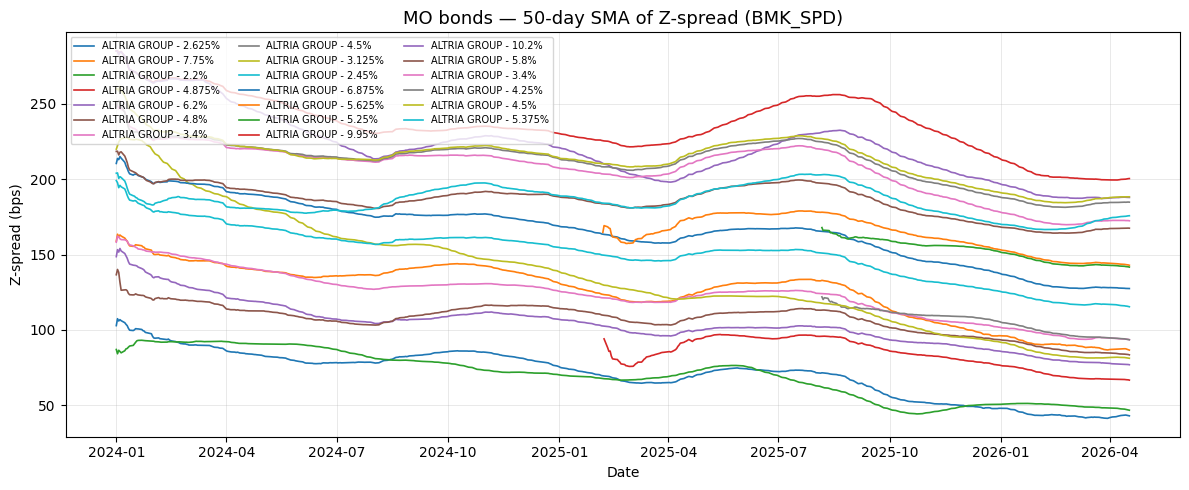

In [6]:
spreads = result["TR.ZSPREAD"]  # DataFrame: index=date, cols=RIC
sma50   = spreads.rolling(100, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 5))

for ric in sma50.columns:
    ax.plot(sma50.index, sma50[ric], linewidth=1.2, label=f"{rics[ric].display_name} - {rics[ric].coupon_rate}%")

ax.set_title("MO bonds — 50-day SMA of Z-spread (BMK_SPD)", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Z-spread (bps)")
ax.legend(fontsize=7, ncol=3, loc="upper left")
ax.grid(True, linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
THRESHOLD = 5.0
lows = [ric for ric in sma50.columns if rics[ric].coupon_rate < THRESHOLD]
highs = list(set(sma50.columns) - set(lows))

In [8]:
small_c = len(sma50[lows].columns)
large_c = len(sma50[highs].columns)

print(f'working with {small_c} coupons under {THRESHOLD}%, {large_c} coupons over {THRESHOLD}%')

working with 11 coupons under 5.0%, 9 coupons over 5.0%


In [9]:
with session as client:
    mo_tickers = client.equities.list_securities("Altria Group Inc")
    ordinary_share_l1 = next(filter(lambda l1: l1.ric == 'MO', mo_tickers))
    assert ordinary_share_l1 is not None
    ordinary_share = client.equities.upgrade_l1_equity(ordinary_share_l1)[0]
    
    price_history = client.equities.history(
        ordinary_share, 
        fields=["TR.ClosePrice"],
        interval=quant.Interval.DAY_1,
        start=datetime(2024, 1, 1),
        end=datetime(2026, 4, 18),
    )

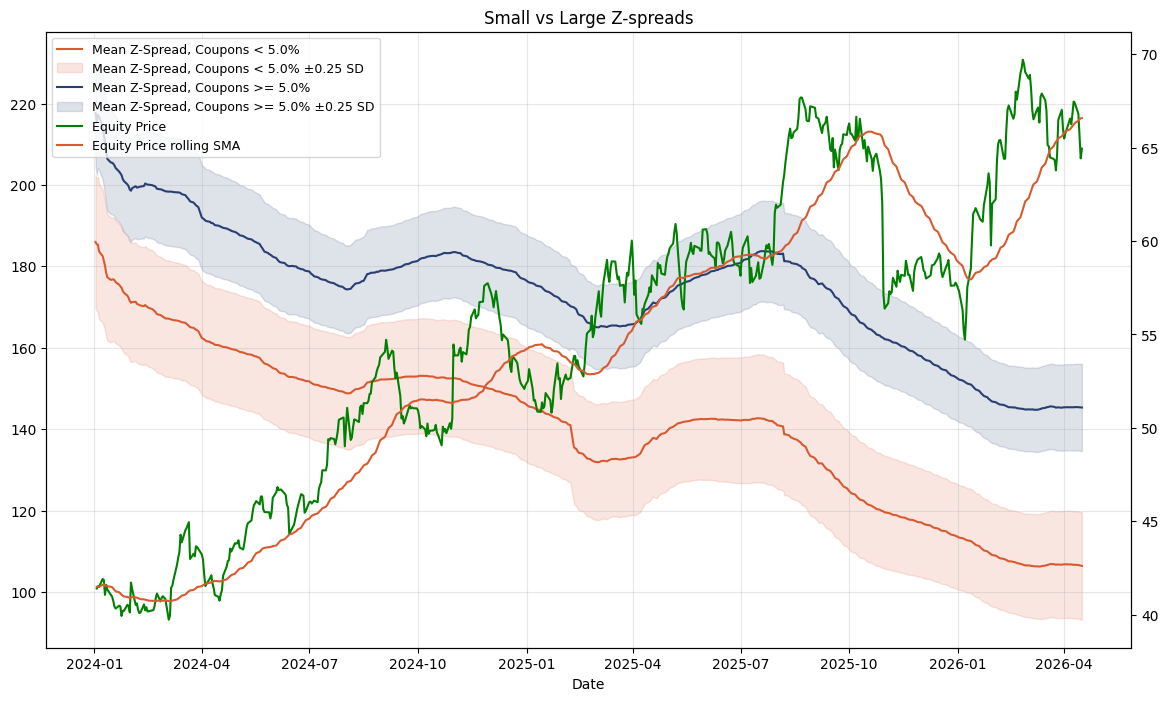

In [10]:
left_axis  = quant.Axis(id="spreads", side="left")
right_axis = quant.Axis(id="equity",  side="right")

small_sg = quant.SeriesGroup([sma50[col] for col in sma50[lows]], axis=left_axis, z=0.25, labels={"title": f"Mean Z-Spread, Coupons < {THRESHOLD}%"})
large_sg = quant.SeriesGroup([sma50[col] for col in sma50[highs]], axis=left_axis, z=0.25, labels={"title": f"Mean Z-Spread, Coupons >= {THRESHOLD}%"})

equity = quant.SeriesGroup([price_history.df], axis=right_axis, labels={"title": "Equity Price"})
equity_sma50_df = price_history.df.rolling(50, min_periods=1).mean()

equity_sma50 = quant.SeriesGroup([equity_sma50_df], axis=right_axis, labels={"title": "Equity Price rolling SMA"})

stack = quant.SeriesGroupStack(
    groups=[small_sg, large_sg, equity, equity_sma50],
    colors=["#d85a30", "#283F71", "green"],
)
fig, ax = stack.plot(title="Small vs Large Z-spreads")
plt.show()


In [11]:
with session as client:
    mo_tickers   = client.equities.list_securities("Altria Group Inc")
    ordinary_l1  = next(filter(lambda l1: l1.ric == "MO", mo_tickers))
    ordinary     = client.equities.upgrade_l1_equity(ordinary_l1)[0]

    eq_history   = client.equities.history_df(
        ordinary,
        fields=["TR.ClosePrice", "TR.PriceToBookValue"],
        interval=quant.Interval.DAY_1,
        start=datetime(2024, 1, 1),
        end=datetime(2026, 4, 18),
    )

In [12]:
close    = eq_history["Close Price"].dropna()
eq_vol   = close.pct_change().rolling(60, min_periods=20).std() * (252 ** 0.5)
shares   = ordinary.shares_outstanding                 # units must match bond AMT_OS
eq_value = close * shares

In [13]:
base_inputs = quant.kmv.kmv_inputs_from_bonds(
    equity_value=float(eq_value.iloc[0]),
    equity_volatility=float(eq_vol.iloc[0]),
    bonds=bonds_l2,
    risk_free_rate=0.05,
)

In [14]:
common_idx = eq_value.index.intersection(eq_vol.index)

panel = pd.DataFrame({
    "equity_value":      eq_value.reindex(common_idx),
    "equity_volatility": eq_vol.reindex(common_idx),
    "z_spread":          spreads.mean(axis=1).reindex(common_idx),   # mean across all MO bonds
}, index=common_idx).dropna()

ts = quant.kmv_timeseries.build_from_panel(panel, base_inputs=base_inputs, name="Altria Group (MO)")

In [15]:
ts_df       = ts.to_dataframe()
dd_df       = ts_df[["dd"]].rename(columns={"dd": "DD (σ)"})
zspread_df  = ts_df[["z_spread"]].rename(columns={"z_spread": "Observed Z-spread"})
fvspread_df = ts_df[["fv_spread_bps"]].rename(columns={"fv_spread_bps": "EDF fair-value spread"})
basis_df    = ts_df[["basis_bps"]].rename(columns={"basis_bps": "Basis (obs − model)"})

In [16]:
dd_axis     = quant.Axis(id="dd",      side="left")
spread_axis = quant.Axis(id="spreads", side="right")

30 days chosen

> The Review of Financial Studies, May, 2008, Vol. 21, No. 3 (May, 2008), pp. 1339-1369.   
> [Link](https://www.jstor.org/stable/40056852)

In [17]:
dd_sg = quant.SeriesGroup(
    [dd_df.rolling(30).mean()],
    axis=dd_axis,
    labels={"title": "Distance to Default (σ) Rolling Average"},
)
zspread_sg = quant.SeriesGroup(
    [zspread_df],
    axis=spread_axis,
    labels={"title": "Observed Z-spread (bps)"},
)
fvspread_sg = quant.SeriesGroup(
    [fvspread_df],
    axis=spread_axis,
    z=0.5,
    labels={"title": "EDF fair-value spread (bps)"},
)
basis_sg = quant.SeriesGroup(
    [basis_df],
    axis=spread_axis,
    z=0.25,
    labels={"title": "Basis: observed − fair-value (bps)"},
)

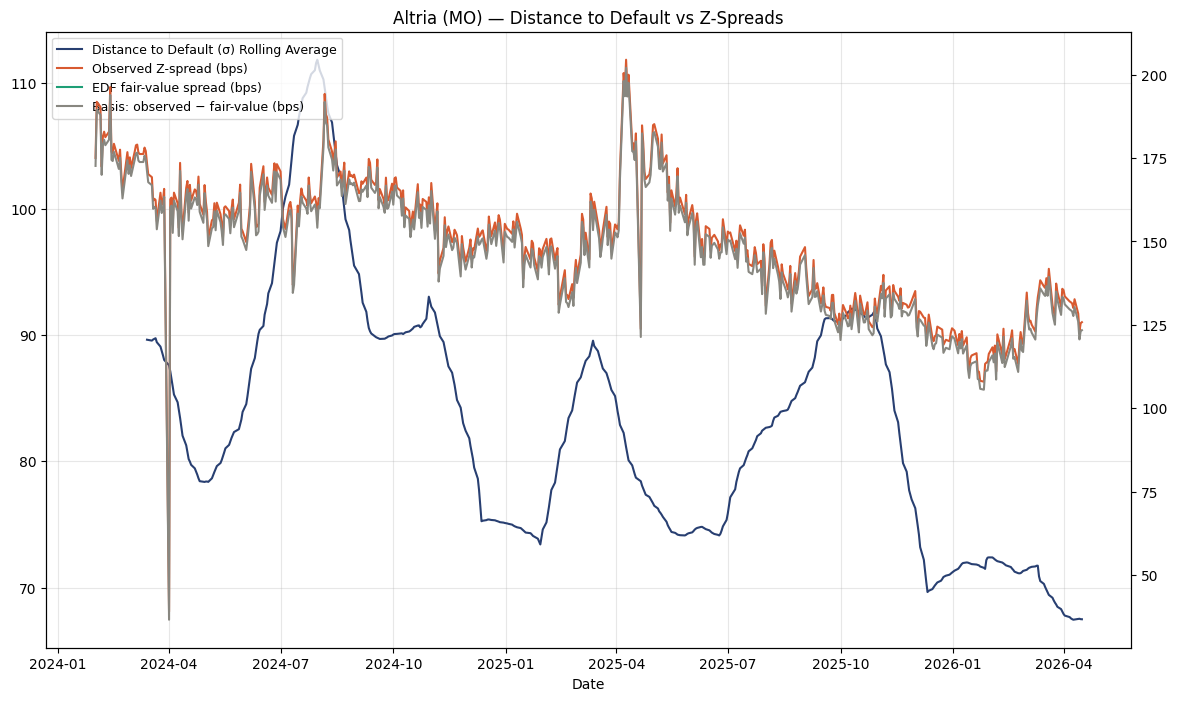

In [18]:
stack = quant.SeriesGroupStack(
    groups=[dd_sg, zspread_sg, fvspread_sg, basis_sg],
    colors=["#283F71", "#d85a30", "#1D9E75", "#888780"],
)

fig, ax = stack.plot(title="Altria (MO) — Distance to Default vs Z-Spreads")
plt.show()